In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import sqlite3


In [2]:
conn=sqlite3.connect("/home/adi/Documents/project/data/inventory.db")

In [3]:
tables=pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'",conn)

In [4]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [5]:
type(tables)

pandas.DataFrame

In [6]:
for table in tables['name']:
    print(table)
    df=pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [7]:
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)

In [8]:
vendor_df.sample()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
956,7255,PSP WINES,2024-03-09,9074,2024-02-24,2024-04-24,117,890.43,4.36,NaN


Text(0.5, 1.0, 'Correlation between Quantity, Dollars, and Freight')

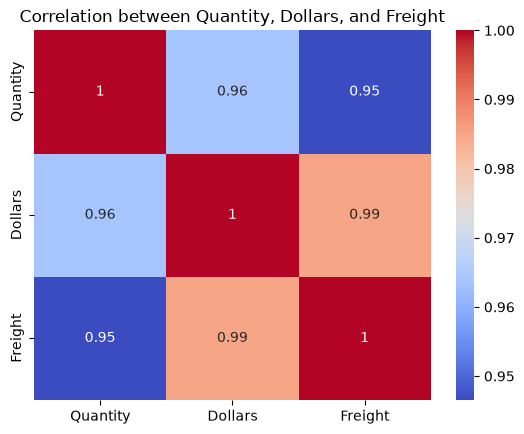

In [9]:
sns.heatmap(vendor_df[["Quantity", "Dollars", "Freight"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Quantity, Dollars, and Freight")

Text(0, 0.5, '')

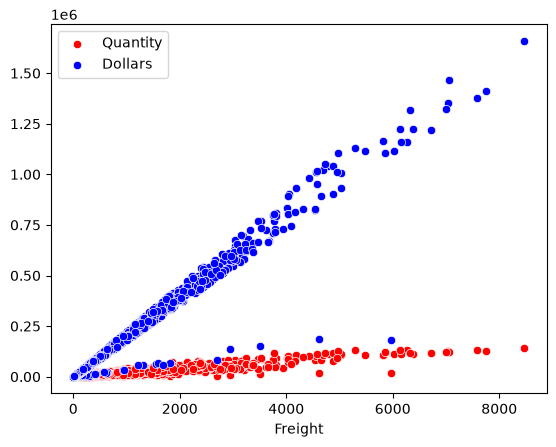

In [10]:
sns.scatterplot(data=vendor_df,y="Quantity",x="Freight",color="red")
sns.scatterplot(data=vendor_df,y="Dollars",x="Freight",color="blue")
plt.legend(["Quantity","Dollars"])
plt.ylabel(None)

In [11]:
vendor_df["Freight_per_unit"]=vendor_df["Freight"]/vendor_df["Quantity"]

In [12]:
vendor_df.sample()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_per_unit
4537,17032,JEWELL TOWNE VINEYARDS,2024-11-07,12660,2024-10-18,2024-12-10,118,912.8,4.38,NaN,0.037119


In [13]:
X=vendor_df[["Quantity","Dollars"]]
Y=vendor_df["Freight"]

In [14]:
X

,Quantity,Dollars
0,6,214.26
1,15,140.55
2,5,106.60
3,10100,137483.78
4,1935,15527.25
...,...,...
5538,90,1563.00
5539,4617,37300.48
5540,9848,202815.78
5541,24747,149007.56


In [15]:
Y

0          3.47
1          8.57
2          4.61
3       2935.20
4        429.20
         ...   
5538       8.60
5539     186.50
5540     932.95
5541     819.54
5542      16.60
Name: Freight, Length: 5543, dtype: float64

In [16]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Quantity  5543 non-null   int64  
 1   Dollars   5543 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 86.7 KB


In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import svm
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import r2_score

In [19]:
model1=LinearRegression()
model2=DecisionTreeRegressor(random_state=42)
model3=RandomForestRegressor(random_state=42)
model4=svm.SVR()

In [20]:
model1.fit(x_train,y_train)
model2.fit(x_train,y_train)
model3.fit(x_train,y_train)
model4.fit(x_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [21]:
pred1=model1.predict(x_test)
pred2=model2.predict(x_test)
pred3=model3.predict(x_test)
pred4=model4.predict(x_test)

In [22]:
mse1=mean_squared_error(y_test,pred1)
mse2=mean_squared_error(y_test,pred2)
mse3=mean_squared_error(y_test,pred3)
mse4=mean_squared_error(y_test,pred4)

In [23]:
abs_error1=mean_absolute_error(y_test,pred1)
abs_error2=mean_absolute_error(y_test,pred2)
abs_error3=mean_absolute_error(y_test,pred3)
abs_error4=mean_absolute_error(y_test,pred4)

In [24]:
r2_1=r2_score(y_test,pred1)
r2_2=r2_score(y_test,pred2)
r2_3=r2_score(y_test,pred3)
r2_4=r2_score(y_test,pred4)

In [25]:
result=pd.DataFrame([['Linear Regression',mse1,abs_error1,r2_1],
                    ['Decision Tree Regression',mse2,abs_error2,r2_2],
                    ['Random Forest Regression',mse3,abs_error3,r2_3],
                     ['SVM',mse4,abs_error4,r2_4],
                    ],columns=['Model','MSE','MAE','R2 Score'])
                     

In [26]:
result.head()

,Model,MSE,MAE,R2 Score
0,Linear Regression,15482.522465,24.459181,0.970020
1,Decision Tree Regression,33306.529083,33.868418,0.935505
2,Random Forest Regression,19220.790128,27.652772,0.962781
3,SVM,355444.254031,140.157841,0.311720


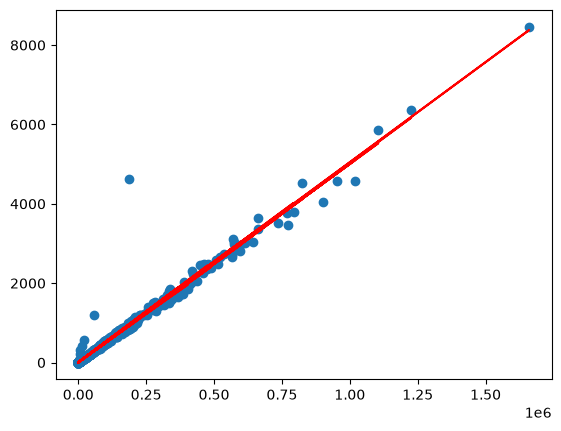

In [27]:
plt.scatter(x_test['Dollars'],y_test)
#plt.scatter(x_test['Quantity'],y_test)
plt.plot(x_test['Dollars'],pred1,color="red")